# investalyze: data log (findings + decisions)

A running, reproducible record of data quirks (characteristics of the data itself) and the decisions
they drive. Each entry says what the quirk is, why it exists, and that it is genuine data, not a mistake.
One markdown cell + one code cell per entry, grouped under the **Pending** and **Fixed** chapters,
newest on top within each. Committed with outputs.

Status legend: ✅ understood · 🔶 open question · ❓ to verify

Entry template: header `### <ticker / topic>: <one-line>  <status>`, then **What:**, **Why:** and,
once corrected via the cleaning package, **Fix:**.

## Index

Pending
- none currently

Fixed
- Pre-launch/pre-base index history was fabricated (`^NDX`, `^NDQ`, `^NKX`, `^AOR`, `^CAC`, `^IBEX`, `^PX`, `^NOMUC`, `^SPX`, `^UKX`, `^TSX`, `^PSEI`) ✅
- `^MRV` (Merval): index level spans ~8 orders of magnitude ✅

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from helpers import connect_readonly, get_ticker_rows

con = connect_readonly()

## Pending

Open quirks, to investigate.

## Fixed

Resolved quirks: corrected via the cleaning package, or understood and kept as genuine data.

### Pre-launch/pre-base index history was fabricated ✅ fixed

**What**: the actual data problem: twelve tickers had rows in the DB from before the real index
existed (or before its own official retroactive base), and none of that history is genuine, regardless
of how it was found:

| Ticker | Real base/launch | DB had data from | Rows deleted | How found |
|---|---|---|---|---|
| `^NDX` | 1985-10-02 | 1938 | 12,585 | constant ratio to `^NDQ` (std < 0.001) |
| `^NDQ` | 1971-02-08 | 1938 | 8,885 | a subset exactly duplicated `^SPX` |
| `^NKX` | 1949-05-16 | 1914 | 142 | index-launch-date audit |
| `^AOR` | 1979-12-31 | 1875 | 1,260 | index-launch-date audit |
| `^CAC` | 1987-12-31 | 1965 | 4,909 | index-launch-date audit |
| `^IBEX` | 1989-12-29 | 1987 | 737 | index-launch-date audit |
| `^PX` | 1994-04-05 | 1993 | 50 | index-launch-date audit |
| `^NOMUC` | 2019-03-21 | 2018 | 306 | index-launch-date audit |
| `^SPX` | 1923-01-01 | 1789 | 12,402 | index-launch-date audit |
| `^UKX` | 1984-01-03 | 1935 | 12,392 | index-launch-date audit |
| `^TSX` | 1977-01-03 | 1956 | 252 | index-launch-date audit |
| `^PSEI` | 1990-02-28 | 1986 | 1,084 | index-launch-date audit |

**Why**: vendor backfill. Before the real index (or its own recognized retroactive base) existed, the
vendor filled the gap with a substitute, another ticker's scaled or exact values, or an independent
third-party reconstruction, rather than leaving it absent. Whether the substitute matches another
series exactly or just looks like plausible independent data doesn't matter: if the real index didn't
exist yet, nothing under that ticker for that period is genuine. `^SPX`'s cutoff uses 1923 (Standard
Statistics' own predecessor index, per S&P Dow Jones Indices' own history), not the 1957 S&P 500
launch, that earlier data is real S&P lineage, only the pre-1923 stretch (to 1789) is unexplained.

**Fix**: twelve `[[delete_date_range]]` entries in `cleaning.toml`, 55,004 rows total. `^NDX`/`^NDQ`
applied; the rest pending (`python -m investalyze.cleaning apply`).

In [2]:
checks = [
    ('^NDX', '1985-10-01'),
    ('^NDQ', '1971-02-07'),
    ('^NKX', '1949-05-15'),
    ('^AOR', '1979-12-30'),
    ('^CAC', '1987-12-30'),
    ('^IBEX', '1989-12-28'),
    ('^PX', '1994-04-04'),
    ('^NOMUC', '2019-03-20'),
    ('^SPX', '1922-12-31'),
    ('^UKX', '1984-01-02'),
    ('^TSX', '1977-01-02'),
    ('^PSEI', '1990-02-27'),
]
for ticker, base_end in checks:
    rows = get_ticker_rows(con, 'market_data', ticker)
    pre_base = rows[rows['Date'] <= base_end]
    if len(pre_base) == 0:
        print(f'{ticker}: 0 pre-base rows (fix applied, clean)')
    else:
        print(f'{ticker}: {len(pre_base)} pre-base rows (fix pending, run python -m investalyze.cleaning apply)')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

^NDX: 0 pre-base rows (fix applied, clean)
^NDQ: 0 pre-base rows (fix applied, clean)


^NKX: 142 pre-base rows (fix pending, run python -m investalyze.cleaning apply)


^AOR: 1260 pre-base rows (fix pending, run python -m investalyze.cleaning apply)


^CAC: 4909 pre-base rows (fix pending, run python -m investalyze.cleaning apply)
^IBEX: 737 pre-base rows (fix pending, run python -m investalyze.cleaning apply)
^PX: 50 pre-base rows (fix pending, run python -m investalyze.cleaning apply)
^NOMUC: 306 pre-base rows (fix pending, run python -m investalyze.cleaning apply)


^SPX: 12402 pre-base rows (fix pending, run python -m investalyze.cleaning apply)
^UKX: 12392 pre-base rows (fix pending, run python -m investalyze.cleaning apply)
^TSX: 252 pre-base rows (fix pending, run python -m investalyze.cleaning apply)
^PSEI: 1084 pre-base rows (fix pending, run python -m investalyze.cleaning apply)


### `^MRV` (Merval, Argentina): index level spans ~8 orders of magnitude ✅

**What**: `^MRV`, the Argentine Merval index, has an enormous **dynamic range**: its nominal level runs
from ~0.03 (1988) to ~3.3M (2026), roughly **8 orders of magnitude**. This is **genuine data, not a feed
glitch**.

**Why**: decades of Argentine **hyperinflation** plus several **currency redenominations** inflate the
index.

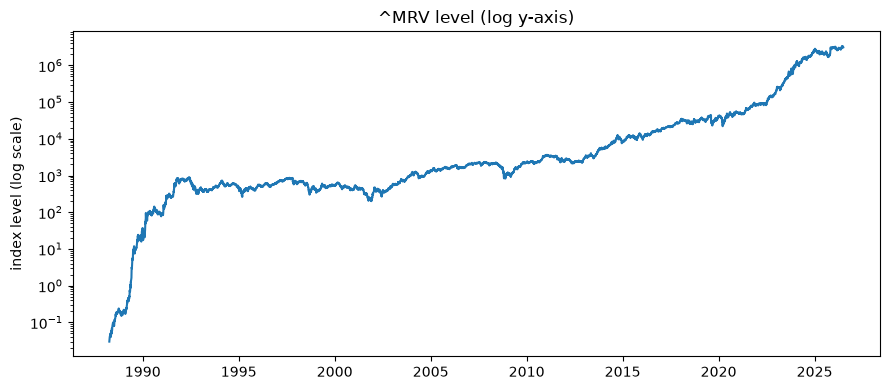

level range 0.03 to 3,353,008, span x111,766,925 (~8.0 orders of magnitude)


In [3]:
TICKER = '^MRV'

mrv = get_ticker_rows(con, 'market_data', TICKER).sort_values('Date')
price = mrv['C'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mrv['Date'], price)
ax.set_yscale('log')
ax.set_title(f'{TICKER} level (log y-axis)')
ax.set_ylabel('index level (log scale)')
plt.tight_layout()
plt.show()

span = price.max() / price.min()
print(f'level range {price.min():g} to {price.max():,.0f}, span x{span:,.0f} (~{np.log10(span):.1f} orders of magnitude)')

---